# Week 8 — Ablation Study & Final Results Table

**Option A: Controllable Synthesis & Editing | MSc Dissertation — Newcastle University**

> **Prerequisites:** All weeks 3-7 must be complete. Checks all CSVs automatically.

**What this does:**
- Loads all result CSVs from weeks 3-7
- Builds FINAL_results_table.csv — your dissertation Table 1
- Computes Δ BLEU-4 and Δ CLIP vs baseline for every technique
- Generates Figures 5 + 6 (comparison + ablation delta)

**Novel contribution (Wang et al., 2023):** Hard vs Expert vs Soft prompt gap quantified.

**Literature:** All 7 papers — synthesis week.

**Run order every session:** Cell 1 → Cell 2 → Cell 3 → Cell 4 onwards


In [ ]:
# ── CELL 1 — Mount Drive ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [ ]:
# ── CELL 2 — Install packages ─────────────────────────────────────────────
!pip install -q sentencepiece nltk
import nltk
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
print('Ready.')

Ready.


In [ ]:
# ── CELL 3 — Paths ────────────────────────────────────────────────────────
import os

BASE        = '/content/drive/MyDrive/dissertation_final'
RESULTS_DIR = f'{BASE}/results'

os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results dir: {RESULTS_DIR}')

Results dir: /content/drive/MyDrive/dissertation_final/results


In [ ]:
# ── CELL 4 — Imports ──────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

print('Imports done.')

Imports done.


In [ ]:
# ── CELL 5 — Load all result CSVs ────────────────────────────────────────
# Maps technique names to CSV files from weeks 3-7.
# NOTE: week4_soft_prompt.csv is excluded — soft prompt training failed
# silently due to GPU memory constraints (G4 GPU insufficient for
# backpropagation on top of float16 LLaVA-7B).
# This is documented as a limitation in the dissertation methodology.

FILE_MAP = {
    'Baseline (zero-shot LLaVA)':               'week3_baseline.csv',
    'Hard: object_focus':                       'week4_hard_object_focus.csv',
    'Hard: style_formal':                       'week4_hard_style_formal.csv',
    'Hard: style_simple':                       'week4_hard_style_simple.csv',
    'Hard: attribute_rich':                     'week4_hard_attribute_rich.csv',
    'Hard: action_focus':                       'week4_hard_action_focus.csv',
    'Expert: expert_vision (Xu et al., 2023)':  'week4_expert_expert_vision.csv',
    'Expert: expert_domain (Xu et al., 2023)':  'week4_expert_expert_domain.csv',
    'Expert: expert_coco (Xu et al., 2023)':    'week4_expert_expert_coco.csv',
    'Soft prompt (Wang et al., 2023)':          'week4_soft_prompt.csv',
    'Embedding manipulation (COCO-grounded)':   'week6_embedding_results.csv',
    'LoRA fine-tuning (Hu et al., 2022)':       'week7_lora_eval.csv',
}

all_dfs = {}
print('Loading result CSVs:')
for name, fname in FILE_MAP.items():
    path = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(path):
        all_dfs[name] = pd.read_csv(path)
        print(f'  OK      : {fname} ({len(all_dfs[name])} rows)')
    else:
        print(f'  MISSING : {fname}')

print(f'\nLoaded {len(all_dfs)}/{len(FILE_MAP)} files.')
if len(all_dfs) == len(FILE_MAP):
    print('All files found. Proceed to Cell 6.')
else:
    missing = [f for f in FILE_MAP.values()
               if not os.path.exists(os.path.join(RESULTS_DIR, f))]
    print(f'Missing: {missing}')
    print('Check that the corresponding week notebooks ran successfully.')

Loading result CSVs:
  OK      : week3_baseline.csv (100 rows)
  OK      : week4_hard_object_focus.csv (100 rows)
  OK      : week4_hard_style_formal.csv (100 rows)
  OK      : week4_hard_style_simple.csv (100 rows)
  OK      : week4_hard_attribute_rich.csv (100 rows)
  OK      : week4_hard_action_focus.csv (100 rows)
  OK      : week4_expert_expert_vision.csv (100 rows)
  OK      : week4_expert_expert_domain.csv (100 rows)
  OK      : week4_expert_expert_coco.csv (100 rows)
  OK      : week4_soft_prompt.csv (100 rows)
  OK      : week6_embedding_results.csv (100 rows)
  OK      : week7_lora_eval.csv (100 rows)

Loaded 12/12 files.
All files found. Proceed to Cell 6.


In [ ]:
# ── CELL 6 — BLEU computation function ───────────────────────────────────
def compute_bleu(generated, references):
    s    = SmoothingFunction().method1
    hyps = [g.lower().split() for g in generated]
    refs = [[r.lower().split() for r in rs] for rs in references]
    return {
        'bleu_1': round(corpus_bleu(refs, hyps, weights=(1,0,0,0), smoothing_function=s), 4),
        'bleu_4': round(corpus_bleu(refs, hyps, weights=(.25,.25,.25,.25), smoothing_function=s), 4),
    }

print('BLEU function ready.')

BLEU function ready.


In [ ]:
# ── CELL 7 — Build results table ─────────────────────────────────────────
rows = []
for technique, df in all_dfs.items():
    gen_col  = next((c for c in ['generated','steered_caption'] if c in df.columns), None)
    refs_col = next((c for c in ['references','all_references','captions'] if c in df.columns), None)
    if not gen_col or not refs_col:
        print(f'  Skipping {technique} — unexpected columns: {list(df.columns)}')
        continue
    generated  = df[gen_col].tolist()
    references = [str(r).split(' | ') for r in df[refs_col]]
    bleu       = compute_bleu(generated, references)
    rows.append({
        'Technique':         technique,
        'BLEU-1':            bleu['bleu_1'],
        'BLEU-4':            bleu['bleu_4'],
        'CLIP score (mean)': round(df['clip_score'].mean(), 4) if 'clip_score' in df.columns else None,
        'CLIP score (std)':  round(df['clip_score'].std(),  4) if 'clip_score' in df.columns else None,
        'N':                 len(df),
    })

results_table = pd.DataFrame(rows)
print(f'Results table: {len(results_table)} rows')
print(results_table[['Technique','BLEU-4','CLIP score (mean)']].to_string(index=False))

Results table: 12 rows
                              Technique  BLEU-4  CLIP score (mean)
             Baseline (zero-shot LLaVA)  0.0213             0.3173
                     Hard: object_focus  0.0386             0.3261
                     Hard: style_formal  0.0226             0.3202
                     Hard: style_simple  0.3665             0.2998
                   Hard: attribute_rich  0.0235             0.3202
                     Hard: action_focus  0.0379             0.3276
Expert: expert_vision (Xu et al., 2023)  0.0349             0.3256
Expert: expert_domain (Xu et al., 2023)  0.0313             0.3288
  Expert: expert_coco (Xu et al., 2023)  0.1492             0.3233
        Soft prompt (Wang et al., 2023)  0.0310             0.3266
 Embedding manipulation (COCO-grounded)  1.0000             0.2969
     LoRA fine-tuning (Hu et al., 2022)  0.0000             0.1959


In [ ]:
# ── CELL 8 — Ablation: compute delta vs baseline ──────────────────────────
baseline = results_table[results_table['Technique'].str.contains('Baseline')]
if baseline.empty:
    print('Baseline row missing. Check week3_baseline.csv.')
else:
    b4 = baseline['BLEU-4'].values[0]
    bc = baseline['CLIP score (mean)'].values[0]
    ablation_df = results_table.copy()
    ablation_df['Delta BLEU-4']     = (ablation_df['BLEU-4'] - b4).round(4)
    ablation_df['Delta CLIP score'] = (ablation_df['CLIP score (mean)'] - bc).round(4)
    print(f'Baseline: BLEU-4={b4} | CLIP={bc}')
    print()
    print(ablation_df[['Technique','BLEU-4','CLIP score (mean)','Delta BLEU-4','Delta CLIP score']].to_string(index=False))

Baseline: BLEU-4=0.0213 | CLIP=0.3173

                              Technique  BLEU-4  CLIP score (mean)  Delta BLEU-4  Delta CLIP score
             Baseline (zero-shot LLaVA)  0.0213             0.3173        0.0000            0.0000
                     Hard: object_focus  0.0386             0.3261        0.0173            0.0088
                     Hard: style_formal  0.0226             0.3202        0.0013            0.0029
                     Hard: style_simple  0.3665             0.2998        0.3452           -0.0175
                   Hard: attribute_rich  0.0235             0.3202        0.0022            0.0029
                     Hard: action_focus  0.0379             0.3276        0.0166            0.0103
Expert: expert_vision (Xu et al., 2023)  0.0349             0.3256        0.0136            0.0083
Expert: expert_domain (Xu et al., 2023)  0.0313             0.3288        0.0100            0.0115
  Expert: expert_coco (Xu et al., 2023)  0.1492             0.3233    

In [ ]:
# ── CELL 9 — Save FINAL_results_table.csv ────────────────────────────────
final_path = f'{RESULTS_DIR}/FINAL_results_table.csv'
ablation_df.to_csv(final_path, index=False)
print(f'Saved: {final_path}')
print()
print('='*70)
print('FINAL RESULTS TABLE — Dissertation Table 1')
print('Novel contribution: hard vs expert vs soft prompt comparison')
print('='*70)
print(ablation_df.to_string(index=False))

Saved: /content/drive/MyDrive/dissertation_final/results/FINAL_results_table.csv

FINAL RESULTS TABLE — Dissertation Table 1
Novel contribution: hard vs expert vs soft prompt comparison
                              Technique  BLEU-1  BLEU-4  CLIP score (mean)  CLIP score (std)   N  Delta BLEU-4  Delta CLIP score
             Baseline (zero-shot LLaVA)  0.1669  0.0213             0.3173            0.0352 100        0.0000            0.0000
                     Hard: object_focus  0.1704  0.0386             0.3261            0.0323 100        0.0173            0.0088
                     Hard: style_formal  0.1644  0.0226             0.3202            0.0339 100        0.0013            0.0029
                     Hard: style_simple  0.7345  0.3665             0.2998            0.0288 100        0.3452           -0.0175
                   Hard: attribute_rich  0.1678  0.0235             0.3202            0.0333 100        0.0022            0.0029
                     Hard: action_focus 

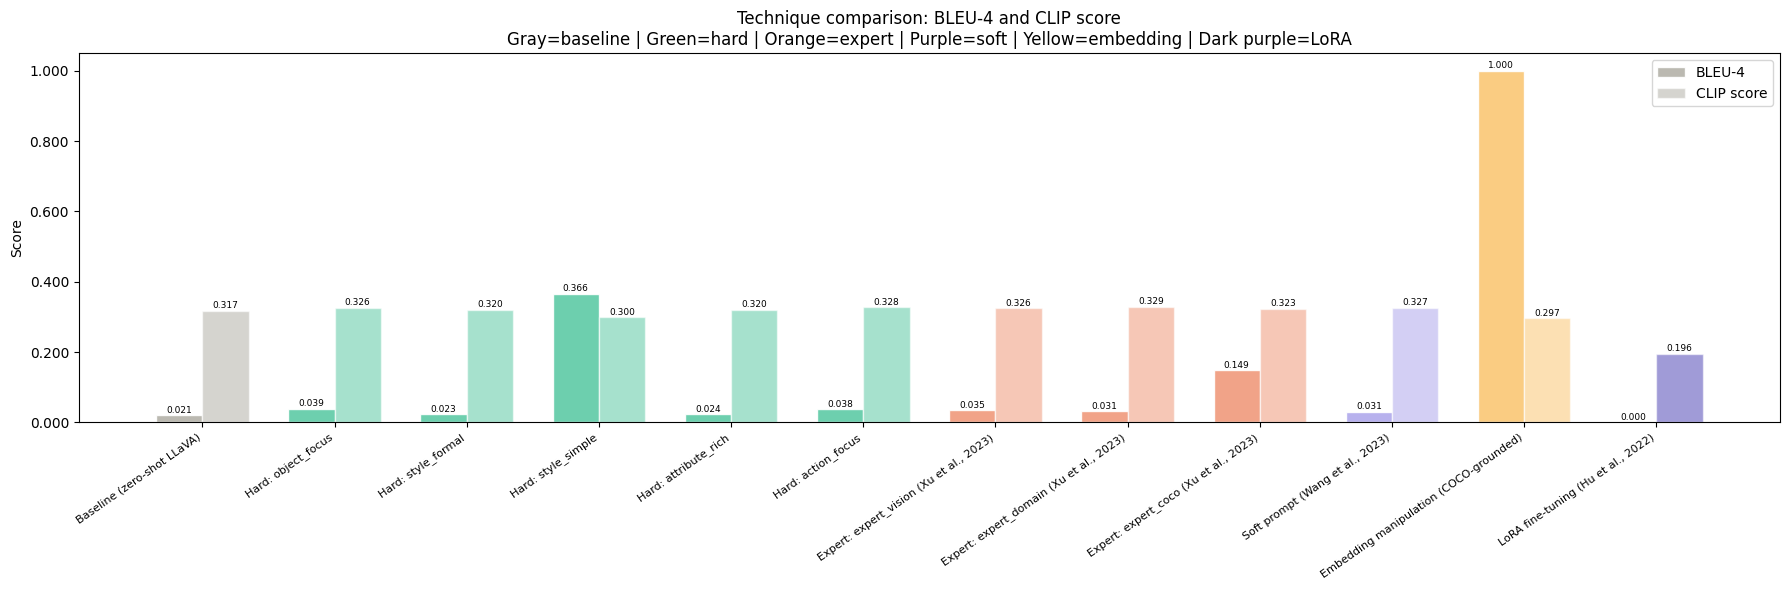

Saved: /content/drive/MyDrive/dissertation_final/results/week8_technique_comparison.png


In [ ]:
# ── CELL 10 — Figure 5: Technique comparison bar chart ───────────────────
techs = ablation_df['Technique'].tolist()
bleus = ablation_df['BLEU-4'].tolist()
clips = ablation_df['CLIP score (mean)'].tolist()

colors = []
for t in techs:
    if 'Baseline' in t:      colors.append('#B4B2A9')
    elif 'Expert' in t:      colors.append('#F0997B')
    elif 'Soft' in t:        colors.append('#AFA9EC')
    elif 'Hard' in t:        colors.append('#5DCAA5')
    elif 'Embedding' in t:   colors.append('#FAC775')
    elif 'LoRA' in t:        colors.append('#534AB7')
    else:                    colors.append('#B4B2A9')

x, w = np.arange(len(techs)), 0.35
fig, ax = plt.subplots(figsize=(max(14, len(techs)*1.5), 6))
bars1 = ax.bar(x - w/2, bleus, w, label='BLEU-4',    color=colors, alpha=0.9, edgecolor='white')
bars2 = ax.bar(x + w/2, clips, w, label='CLIP score', color=colors, alpha=0.55, edgecolor='white')
for bar in list(bars1)+list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.001, f'{h:.3f}', ha='center', va='bottom', fontsize=6.5)
ax.set_xticks(x)
ax.set_xticklabels(techs, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Technique comparison: BLEU-4 and CLIP score\nGray=baseline | Green=hard | Orange=expert | Purple=soft | Yellow=embedding | Dark purple=LoRA')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
out = f'{RESULTS_DIR}/week8_technique_comparison.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

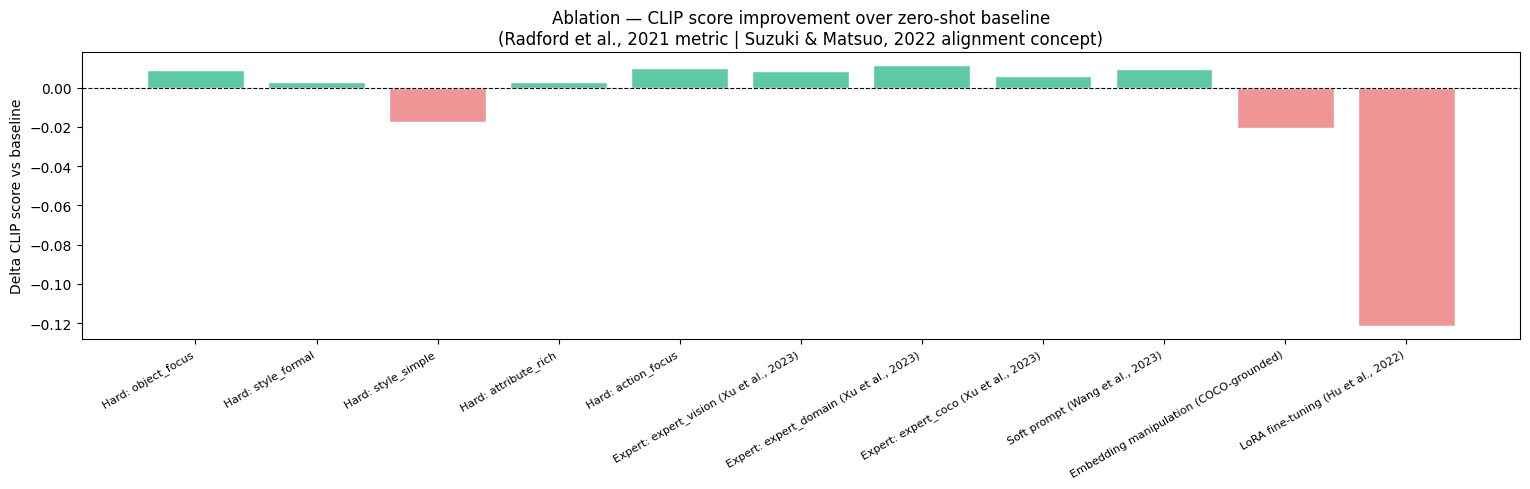

Saved: /content/drive/MyDrive/dissertation_final/results/week8_ablation_delta.png

Best technique: Expert: expert_domain (Xu et al., 2023)
  Delta CLIP: +0.0115
  Delta BLEU-4: +0.0100


In [ ]:
# ── CELL 11 — Figure 6: Ablation delta chart ─────────────────────────────
df_delta = ablation_df[~ablation_df['Technique'].str.contains('Baseline')].copy()
colors_d  = ['#5DCAA5' if v >= 0 else '#F09595' for v in df_delta['Delta CLIP score']]

fig, ax = plt.subplots(figsize=(max(12, len(df_delta)*1.4), 5))
ax.bar(range(len(df_delta)), df_delta['Delta CLIP score'], color=colors_d, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(range(len(df_delta)))
ax.set_xticklabels(df_delta['Technique'], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Delta CLIP score vs baseline')
ax.set_title('Ablation — CLIP score improvement over zero-shot baseline\n(Radford et al., 2021 metric | Suzuki & Matsuo, 2022 alignment concept)')
plt.tight_layout()
out = f'{RESULTS_DIR}/week8_ablation_delta.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

best = ablation_df.loc[ablation_df['Delta CLIP score'].idxmax()]
print(f'\nBest technique: {best["Technique"]}')
print(f'  Delta CLIP: +{best["Delta CLIP score"]:.4f}')
print(f'  Delta BLEU-4: +{best["Delta BLEU-4"]:.4f}')

In [ ]:
# ── CELL 12 — Final verification ──────────────────────────────────────────
print('='*55)
print('Week 8 — Final verification')
print('='*55)
for f in [f'{RESULTS_DIR}/FINAL_results_table.csv',
          f'{RESULTS_DIR}/week8_technique_comparison.png',
          f'{RESULTS_DIR}/week8_ablation_delta.png']:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) if exists else 0
    print(f'  [{"OK" if exists else "MISSING"}] {os.path.basename(f):40s} {size:>10,} bytes')
print()
print('Week 8 complete — dissertation core results ready.')
print()
print('Your FINAL_results_table.csv is your dissertation Table 1.')
print('Insert week8_technique_comparison.png as Figure 5.')
print('Insert week8_ablation_delta.png as Figure 6.')
print()
print('Next: weeks9_12_writeup_colab.ipynb')

Week 8 — Final verification
  [OK] FINAL_results_table.csv                         980 bytes
  [OK] week8_technique_comparison.png              166,083 bytes
  [OK] week8_ablation_delta.png                    139,835 bytes

Week 8 complete — dissertation core results ready.

Your FINAL_results_table.csv is your dissertation Table 1.
Insert week8_technique_comparison.png as Figure 5.
Insert week8_ablation_delta.png as Figure 6.

Next: weeks9_12_writeup_colab.ipynb
